# Time series of Solar heating at the surface



In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from matplotlib.gridspec import GridSpec
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools


import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2016/2908449532.py:46: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


seaborn      : 0.12.2
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
shapely      : 2.0.1
regionmask   : 0.12.1
pint_xarray  : 0.3
cartopy      : 0.21.1
matplotlib   : 3.7.1
geopandas    : 0.13.2
dask_jobqueue: 0.8.2
intake       : 0.7.0
pop_tools    : 2023.3.0
numpy        : 1.23.5
cf_xarray    : 0.8.2
intake_esm   : 2023.6.14
cmocean      : 3.0.3
distributed  : 2023.6.0
xeofs        : 1.0.3
salem        : 0.3.10
xarray       : 2023.6.0



In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

Writing down the equation for change in solar insolation

\begin{equation}
    Q_{\downarrow}^\prime = \overline{Q_{sw}} \bigg(\underbrace{C^\prime (\alpha_w  -  \overline{\alpha_{i}})}_\text{I} - \underbrace{\overline{C}\alpha_{i}^\prime}_\text{II}  - \underbrace{(C^\prime \alpha_{i}^\prime)^\prime}_\text{III}\bigg)+  Q_{sw}^\prime \bigg(\underbrace{ 1- \alpha_w}_\text{IV} +  \underbrace{\overline{C} (\alpha_w - \overline{\alpha_i})}_\text{V}\bigg)  + \underbrace{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}_\text{VI} - \underbrace{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}_\text{VII} - \underbrace{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}_\text{VIII}.
\end{equation}


In [5]:
ds_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_sep_mean_SIA_1920_1950_LENS2.nc')
ds_sw_abs_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_sw_abs_sep_mean_sia_1920_1950_LENS2.nc')

ds_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_sep_mean_SIA_LENS1.nc')
ds_sw_abs_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/warming_terms_sw_abs_sep_mean_sia_LENS1.nc')

In [6]:
ds_q_prime_LENS2 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_1920_1950_LENS2.nc')

ds_q_prime_LENS1 = xr.open_dataset('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_LENS1.nc')

In [7]:
qbar_terms_LENS2 = ds_LENS2.I + ds_LENS2.II + ds_LENS2.III + ds_LENS2.IV + ds_LENS2.V + ds_LENS2.VI + ds_LENS2.VII + ds_LENS2.VIII

qbar_terms_LENS1 = ds_LENS1.I + ds_LENS1.II + ds_LENS1.III + ds_LENS1.IV + ds_LENS1.V + ds_LENS1.VI + ds_LENS1.VII + ds_LENS1.VIII

In [8]:
ds_LENS2['sum'] = qbar_terms_LENS2

ds_LENS1['sum'] = qbar_terms_LENS1

### residual

In [9]:
ds_LENS2['residual'] = (ds_sw_abs_LENS2.sw_abs - ds_LENS2['sum'])

ds_LENS1['residual'] = (ds_sw_abs_LENS1.sw_abs - ds_LENS1['sum'])

In [10]:
ds_new_LENS2 = ds_LENS2.copy()  # optional: keep original intact

# Add ds['V'] to ds['IV']
ds_new_LENS2['IV'] = ds_new_LENS2['IV'] + ds_new_LENS2['V']

# Drop 'V' from the dataset
ds_new_LENS2 = ds_new_LENS2.drop_vars('V')
ds_new_LENS2

ds_new_LENS1 = ds_LENS1.copy()  # optional: keep original intact

# Add ds['V'] to ds['IV']
ds_new_LENS1['IV'] = ds_new_LENS1['IV'] + ds_new_LENS1['V']

# Drop 'V' from the dataset
ds_new_LENS1 = ds_new_LENS1.drop_vars('V')
ds_new_LENS1

<xarray.Dataset>
Dimensions:   (time: 2172, ensemble: 40)
Coordinates:
  * time      (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble  (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 40
    month     (time) int64 ...
Data variables:
    I         (ensemble, time) float64 ...
    II        (ensemble, time) float64 ...
    III       (ensemble, time) float64 ...
    IV        (ensemble, time) float64 -0.01881 0.08052 ... -0.1847 -0.2191
    VI        (ensemble, time) float64 ...
    VII       (ensemble, time) float64 ...
    VIII      (ensemble, time) float64 ...
    sum       (ensemble, time) float64 0.0696 0.223 0.1 ... 2.255 0.1281 0.2207
    residual  (ensemble, time) float64 -0.123 -0.2253 -0.297 ... -0.1281 -0.1945

In [11]:
ds_new_LENS2 = ds_new_LENS2.rename({'VI':'V', 'VII':'VI','VIII':'VII'})

ds_new_LENS1 = ds_new_LENS1.rename({'VI':'V', 'VII':'VI','VIII':'VII'})

In [18]:
# # --- Compute MJJA mean ---
# # Step 1: select May–August
# sel_months_LENS2 = (ds_new_LENS2['time.month'] >= 5) & (ds_new_LENS2['time.month'] <= 8)
# sel_months_LENS1 = (ds_new_LENS1['time.month'] >= 5) & (ds_new_LENS1['time.month'] <= 8)
# ds_mjja_LENS2 = ds_new_LENS2.sel(time=sel_months_LENS2)
# ds_mjja_LENS1 = ds_new_LENS1.sel(time=sel_months_LENS1)

# ds_qprime_mjja_LENS2 = ds_q_prime_LENS2.sel(time=sel_months_LENS2)
# ds_qprime_mjja_LENS1 = ds_q_prime_LENS1.sel(time=sel_months_LENS1)

# # Step 2: group by year (seasonal mean per year)
# ds_mjja_LENS2 = ds_mjja_LENS2.groupby('time.year').mean('time')
# ds_mjja_LENS1 = ds_mjja_LENS1.groupby('time.year').mean('time')

# ds_qprime_mjja_LENS2 = ds_q_prime_LENS2.groupby('time.year').mean('time')
# ds_qprime_mjja_LENS1 = ds_q_prime_LENS1.groupby('time.year').mean('time')

# # # Step 3: ensemble mean
# # ds_mjja_LENS2_mean = ds_mjja_LENS2.mean('ensemble')
# # ds_mjja_LENS1_mean = ds_mjja_LENS1.mean('ensemble')

In [13]:
# import pandas as pd

# # Years from your MJJA datasets
# years_LENS2 = ds_mjja_LENS2.year.values
# years_LENS1 = ds_mjja_LENS1.year.values

# # Function to compute seconds in MJJA of a given year
# def seconds_in_mjja(year):
#     days = 0
#     for month in [5, 6, 7, 8]:
#         # last day of the month → get number of days in that month
#         days_in_month = pd.Period(f"{year}-{month}").days_in_month
#         days += days_in_month
#     return days * 24 * 60 * 60

# # Vectorized over years
# seconds_LENS2 = np.array([seconds_in_mjja(y) for y in years_LENS2])
# seconds_LENS1 = np.array([seconds_in_mjja(y) for y in years_LENS1])

# # Wrap into DataArrays aligned with year
# seconds_LENS2 = xr.DataArray(seconds_LENS2, coords={"year": years_LENS2}, dims="year")
# seconds_LENS1 = xr.DataArray(seconds_LENS1, coords={"year": years_LENS1}, dims="year")


In [14]:
# ds_new_LENS2_cumsum = (ds_mjja_LENS2*seconds_LENS2).cumsum(dim='year')
# ds_new_LENS1_cumsum = (ds_mjja_LENS1*seconds_LENS1).cumsum(dim='year')

In [15]:
# ds_q_prime_LENS2_cumsum = (ds_qprime_mjja_LENS2*seconds_LENS2).cumsum(dim='year')
# ds_q_prime_LENS1_cumsum = (ds_qprime_mjja_LENS1*seconds_LENS1).cumsum(dim='year')

In [16]:
# ds_q_prime_LENS2_cumsum

In [17]:
import pandas as pd
import numpy as np
import xarray as xr

# --- Step 1: Select MJJA months ---
sel_months = (ds_new_LENS2['time.month'] >= 5) & (ds_new_LENS2['time.month'] <= 8)
ds_mjja_LENS2 = ds_new_LENS2.sel(time=sel_months)
ds_mjja_LENS1 = ds_new_LENS1.sel(time=sel_months)

ds_qprime_mjja_LENS2 = ds_q_prime_LENS2.sel(time=sel_months)
ds_qprime_mjja_LENS1 = ds_q_prime_LENS1.sel(time=sel_months)

# --- Step 2: Compute seconds per month for weighting ---
def get_seconds_per_month(time):
    """Return seconds in each time step."""
    return xr.DataArray(
        [pd.Period(f"{t.dt.year.values}-{t.dt.month.values}").days_in_month * 24 * 3600
         for t in time],
        coords={"time": time},
        dims="time"
    )

seconds_per_month_LENS2 = get_seconds_per_month(ds_mjja_LENS2['time'])
seconds_per_month_LENS1 = get_seconds_per_month(ds_mjja_LENS1['time'])

# --- Step 3: Multiply by seconds to integrate over MJJA ---
ds_accum_per_month_LENS2 = ds_mjja_LENS2 * seconds_per_month_LENS2
ds_accum_per_month_LENS1 = ds_mjja_LENS1 * seconds_per_month_LENS1

ds_qprime_accum_per_month_LENS2 = ds_qprime_mjja_LENS2 * seconds_per_month_LENS2
ds_qprime_accum_per_month_LENS1 = ds_qprime_mjja_LENS1 * seconds_per_month_LENS1

# --- Step 4: Sum over MJJA months within each year ---
ds_new_LENS2_accum = ds_accum_per_month_LENS2.groupby('time.year').sum(dim='time')
ds_new_LENS1_accum = ds_accum_per_month_LENS1.groupby('time.year').sum(dim='time')

ds_q_prime_LENS2_accum = ds_qprime_accum_per_month_LENS2.groupby('time.year').sum(dim='time')
ds_q_prime_LENS1_accum = ds_qprime_accum_per_month_LENS1.groupby('time.year').sum(dim='time')

# --- Step 5: (Optional) rename year coordinate for consistency ---
ds_new_LENS2_accum = ds_new_LENS2_accum.rename(year='year')
ds_new_LENS1_accum = ds_new_LENS1_accum.rename(year='year')
ds_q_prime_LENS2_accum = ds_q_prime_LENS2_accum.rename(year='year')
ds_q_prime_LENS1_accum = ds_q_prime_LENS1_accum.rename(year='year')


/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2016/2917690645.py:41: UserWarning: rename 'year' to 'year' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_new_LENS2_accum = ds_new_LENS2_accum.rename(year='year')
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2016/2917690645.py:42: UserWarning: rename 'year' to 'year' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_new_LENS1_accum = ds_new_LENS1_accum.rename(year='year')
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2016/2917690645.py:43: UserWarning: rename 'year' to 'year' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  ds_q_prime_LENS2_accum = ds_q_prime_LENS2_accum.rename(year='year')
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_2016/2917690645.py:44: UserWarning: rename 'year' to 'year' doe

In [103]:
# ds_new_LENS2_cumsum['time']  = ds_new_LENS2['time']
# ds_new_LENS1_cumsum['time']  = ds_new_LENS1['time']

### Plotting all in one : Seasonal average

CPU times: user 1.23 s, sys: 830 ms, total: 2.06 s
Wall time: 2.16 s


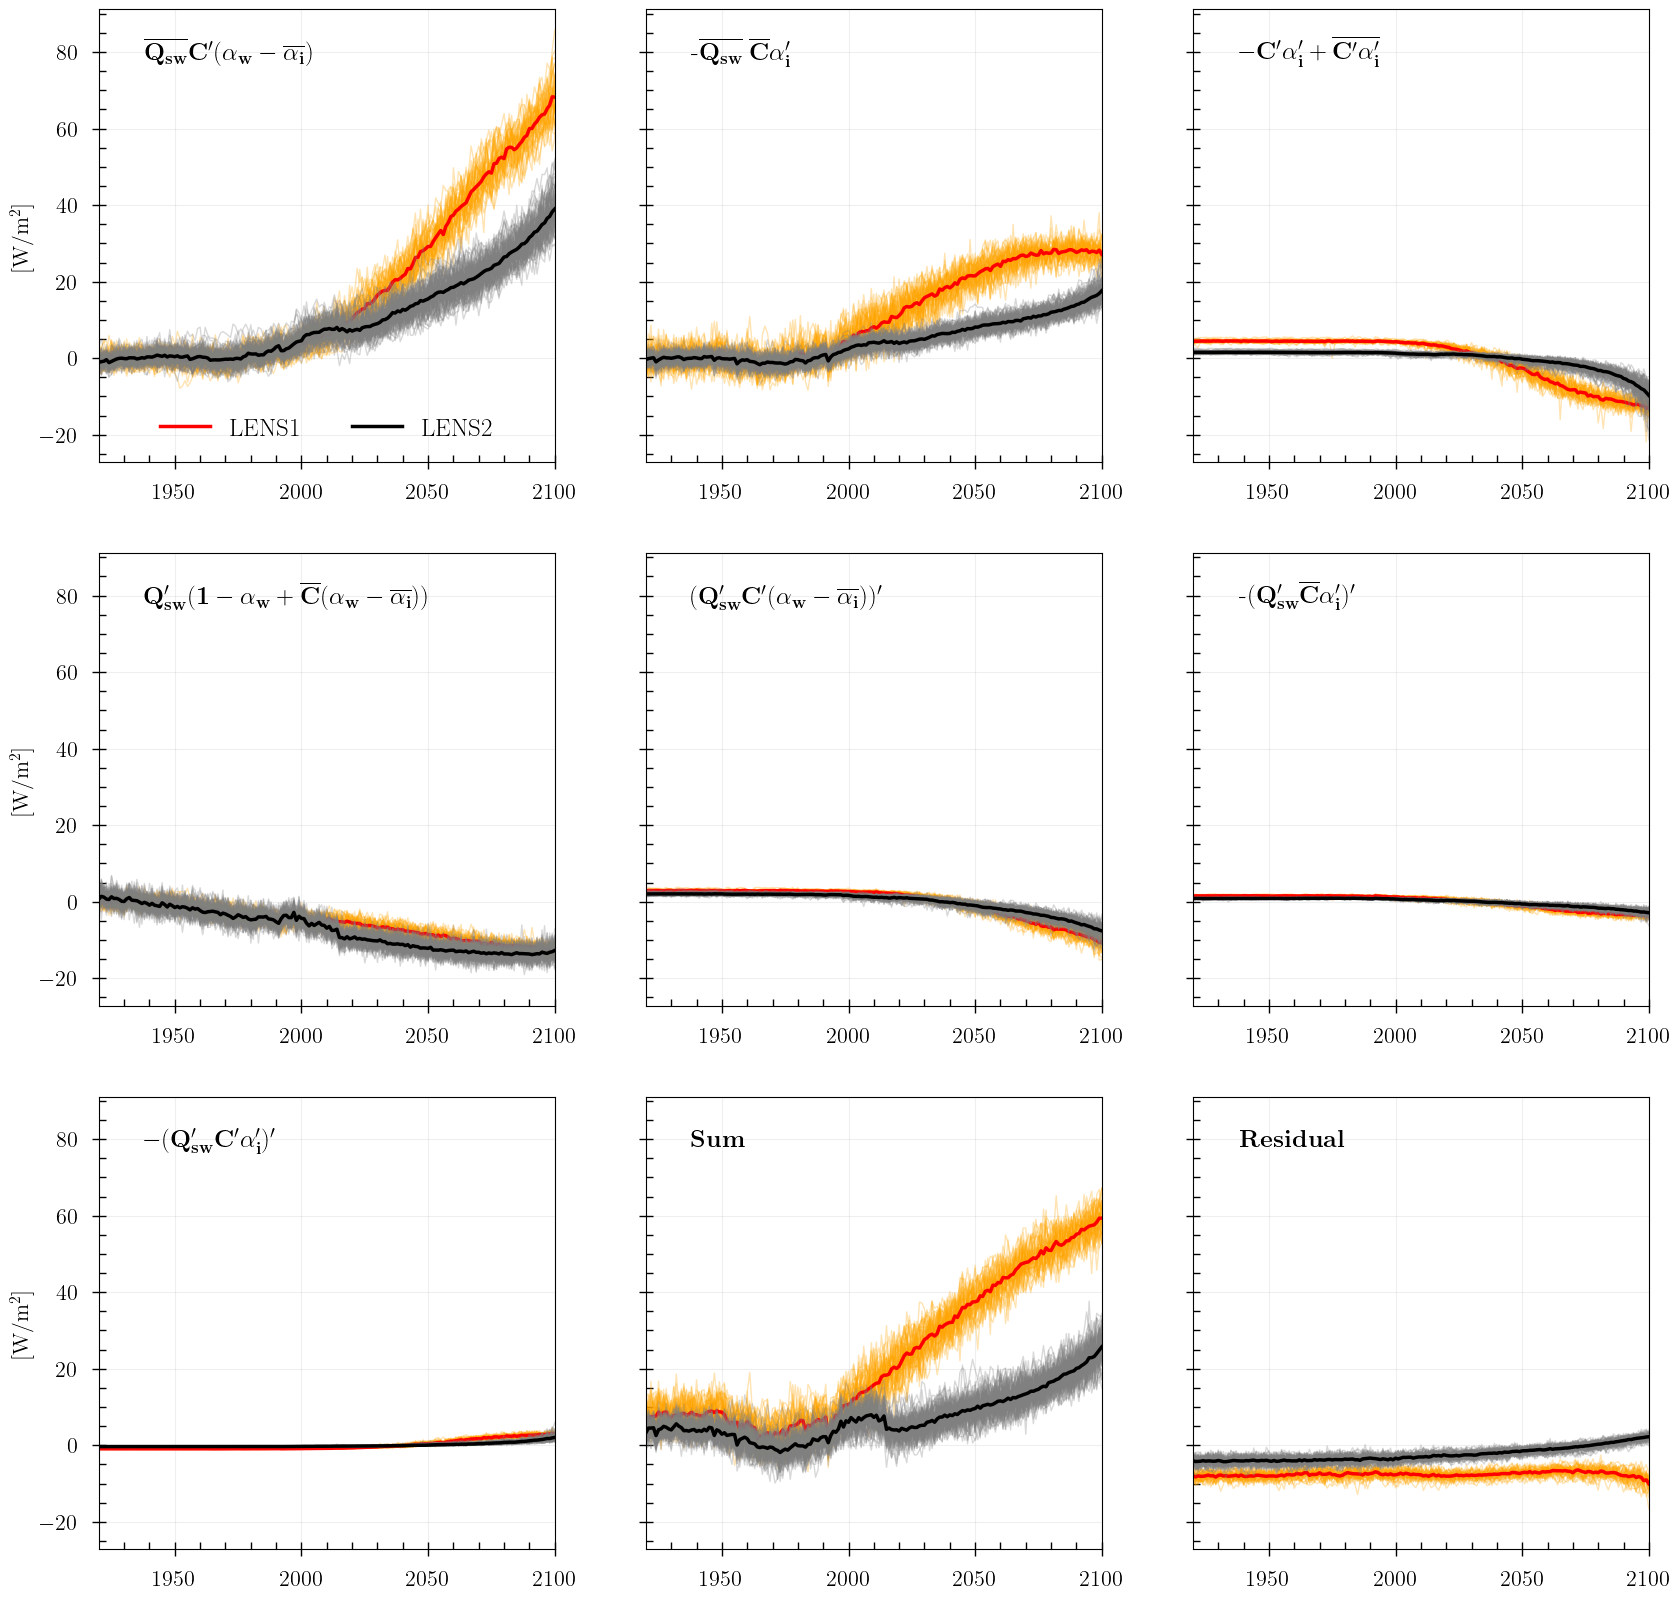

In [20]:
%%time

fig, ax = plt.subplots(ncols=3, nrows=3, sharey=True, figsize=(20, 20))
ax = ax.flatten()

ax_nums = np.linspace(0, 8, 9, dtype=int)

# --- Compute MJJA mean ---
# Step 1: select May–August
sel_months_LENS2 = (ds_new_LENS2['time.month'] >= 5) & (ds_new_LENS2['time.month'] <= 8)
sel_months_LENS1 = (ds_new_LENS1['time.month'] >= 5) & (ds_new_LENS1['time.month'] <= 8)
ds_mjja_LENS2 = ds_new_LENS2.sel(time=sel_months_LENS2)
ds_mjja_LENS1 = ds_new_LENS1.sel(time=sel_months_LENS1)

# Step 2: group by year (seasonal mean per year)
ds_mjja_LENS2 = ds_mjja_LENS2.groupby('time.year').mean('time')
ds_mjja_LENS1 = ds_mjja_LENS1.groupby('time.year').mean('time')

# Step 3: ensemble mean
ds_mjja_LENS2_mean = ds_mjja_LENS2.mean('ensemble')
ds_mjja_LENS1_mean = ds_mjja_LENS1.mean('ensemble')

# ------------------------------------------------------
# Plotting loop
for i, variable in zip(ax_nums, ds_mjja_LENS1.data_vars):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS1.ensemble:
        ax[i].plot(ds_mjja_LENS1.year, ds_mjja_LENS1[variable].sel(ensemble=ensemble),
                   color='orange', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS1_mean.year, ds_mjja_LENS1_mean[variable],
               c='r', lw=2.5, label='LENS1')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS1.year.min().item(), ds_mjja_LENS1.year.max().item())
    
for i, variable in zip(ax_nums, ds_mjja_LENS2.data_vars):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS2.ensemble:
        ax[i].plot(ds_mjja_LENS2.year, ds_mjja_LENS2[variable].sel(ensemble=ensemble),
                   color='gray', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS2_mean.year, ds_mjja_LENS2_mean[variable],
               c='k', lw=2.5, label='LENS2')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS2.year.min().item(), ds_mjja_LENS2.year.max().item())




# ------------------------------------------------------
# Labels
ax[0].set_ylabel(r'[W/m$^2$]', fontsize=16)
ax[3].set_ylabel(r'[W/m$^2$]', fontsize=16)
ax[6].set_ylabel(r'[W/m$^2$]', fontsize=16)

# Math texts
ax[0].text(0.1, 0.89, r'$\mathbf{\overline{Q_{sw}}C^\prime (\alpha_w  - \overline{\alpha_{i}})}$', fontsize=18, transform=ax[0].transAxes)
ax[1].text(0.1, 0.89, r'-$\mathbf{\overline{Q_{sw}} \; \overline{C}\alpha_{i}^\prime}$', fontsize=18, transform=ax[1].transAxes)
ax[2].text(0.1, 0.89, r'$\mathbf{-C^\prime \alpha_{i}^\prime + \overline{C^\prime \alpha_i^\prime}}$', fontsize=18, transform=ax[2].transAxes)
ax[3].text(0.1, 0.89, r'$\mathbf{Q_{sw}^\prime (1- \alpha_w + \overline{C} (\alpha_w - \overline{\alpha_i}))}$', fontsize=18, transform=ax[3].transAxes)
ax[4].text(0.1, 0.89, r'$\mathbf{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}$', fontsize=18, transform=ax[4].transAxes)
ax[5].text(0.1, 0.89, r'-$\mathbf{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[5].transAxes)
ax[6].text(0.1, 0.89, r'$-\mathbf{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[6].transAxes)
ax[7].text(0.1, 0.89, r'\textbf{Sum}', fontsize=18, transform=ax[7].transAxes)
ax[8].text(0.1, 0.89, r'\textbf{Residual}', fontsize=18, transform=ax[8].transAxes)


ax[0].legend(loc='lower center', ncol=2, frameon=False, fontsize=18)

# plt.savefig('figs/terms_in_one_LENS2_LENS1_MJJA_with_ensembles.png', format='png', bbox_inches='tight', dpi=300)


### Only four panels

CPU times: user 873 ms, sys: 865 ms, total: 1.74 s
Wall time: 1.84 s


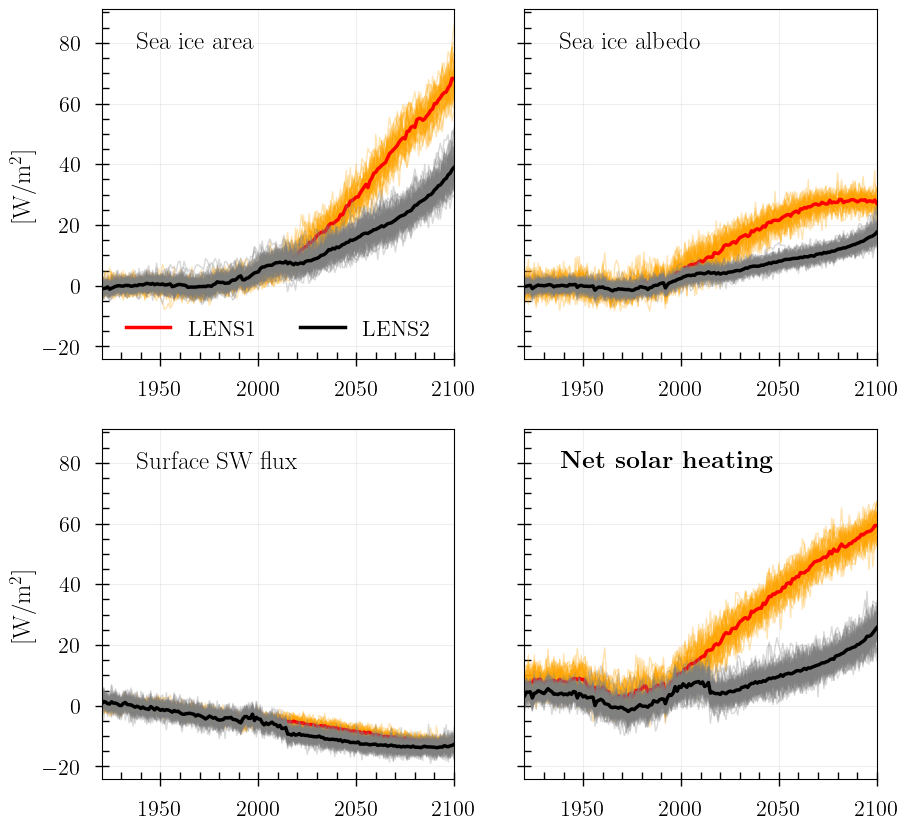

In [21]:
%%time

fig, ax = plt.subplots(ncols=2, nrows=2, sharey=True, figsize=(10,10))
ax = ax.flatten()

ax_nums = np.linspace(0, 3, 4, dtype=int)

# --- Compute MJJA mean ---
# Step 1: select May–August
sel_months_LENS2 = (ds_new_LENS2['time.month'] >= 5) & (ds_new_LENS2['time.month'] <= 8)
sel_months_LENS1 = (ds_new_LENS1['time.month'] >= 5) & (ds_new_LENS1['time.month'] <= 8)
ds_mjja_LENS2 = ds_new_LENS2.sel(time=sel_months_LENS2)
ds_mjja_LENS1 = ds_new_LENS1.sel(time=sel_months_LENS1)

# Step 2: group by year (seasonal mean per year)
ds_mjja_LENS2 = ds_mjja_LENS2.groupby('time.year').mean('time')
ds_mjja_LENS1 = ds_mjja_LENS1.groupby('time.year').mean('time')

# Step 3: ensemble mean
ds_mjja_LENS2_mean = ds_mjja_LENS2.mean('ensemble')
ds_mjja_LENS1_mean = ds_mjja_LENS1.mean('ensemble')

variables_to_plot = ['I','II','IV','sum']
# ------------------------------------------------------
# Plotting loop
for i, variable in zip(ax_nums, variables_to_plot):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS1.ensemble:
        ax[i].plot(ds_mjja_LENS1.year, ds_mjja_LENS1[variable].sel(ensemble=ensemble),
                   color='orange', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS1_mean.year, ds_mjja_LENS1_mean[variable],
               c='r', lw=2.5, label='LENS1')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS1.year.min().item(), ds_mjja_LENS1.year.max().item())
    
for i, variable in zip(ax_nums, variables_to_plot):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS2.ensemble:
        ax[i].plot(ds_mjja_LENS2.year, ds_mjja_LENS2[variable].sel(ensemble=ensemble),
                   color='gray', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS2_mean.year, ds_mjja_LENS2_mean[variable],
               c='k', lw=2.5, label='LENS2')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS2.year.min().item(), ds_mjja_LENS2.year.max().item())




# ------------------------------------------------------
# Labels
ax[0].set_ylabel(r'[W/m$^2$]', fontsize=18)
ax[2].set_ylabel(r'[W/m$^2$]', fontsize=18)
# ax[6].set_ylabel(r'[W/m$^2$]', fontsize=16)

# Math texts
ax[0].text(0.1, 0.89, r'Sea ice area', fontsize=18, transform=ax[0].transAxes)
ax[1].text(0.1, 0.89, r'Sea ice albedo', fontsize=18, transform=ax[1].transAxes)
# ax[2].text(0.1, 0.89, r'$\mathbf{-C^\prime \alpha_{i}^\prime + \overline{C^\prime \alpha_i^\prime}}$', fontsize=18, transform=ax[2].transAxes)
ax[2].text(0.1, 0.89, r'Surface SW flux ', fontsize=18, transform=ax[2].transAxes)
# ax[4].text(0.1, 0.89, r'$\mathbf{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}$', fontsize=18, transform=ax[4].transAxes)
# ax[5].text(0.1, 0.89, r'-$\mathbf{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[5].transAxes)
# ax[6].text(0.1, 0.89, r'$-\mathbf{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[6].transAxes)
ax[3].text(0.1, 0.89, r'\textbf{Net solar heating}', fontsize=18, transform=ax[3].transAxes)
# ax[8].text(0.1, 0.89, r'\textbf{Residual}', fontsize=18, transform=ax[8].transAxes)


ax[0].legend(loc='lower center', ncol=2, frameon=False, fontsize=16)

# plt.savefig('figs/time_series_figure.png', format='png', bbox_inches='tight', dpi=300)


### Plotting the accumulated solar heating

CPU times: user 779 ms, sys: 17.6 ms, total: 796 ms
Wall time: 903 ms


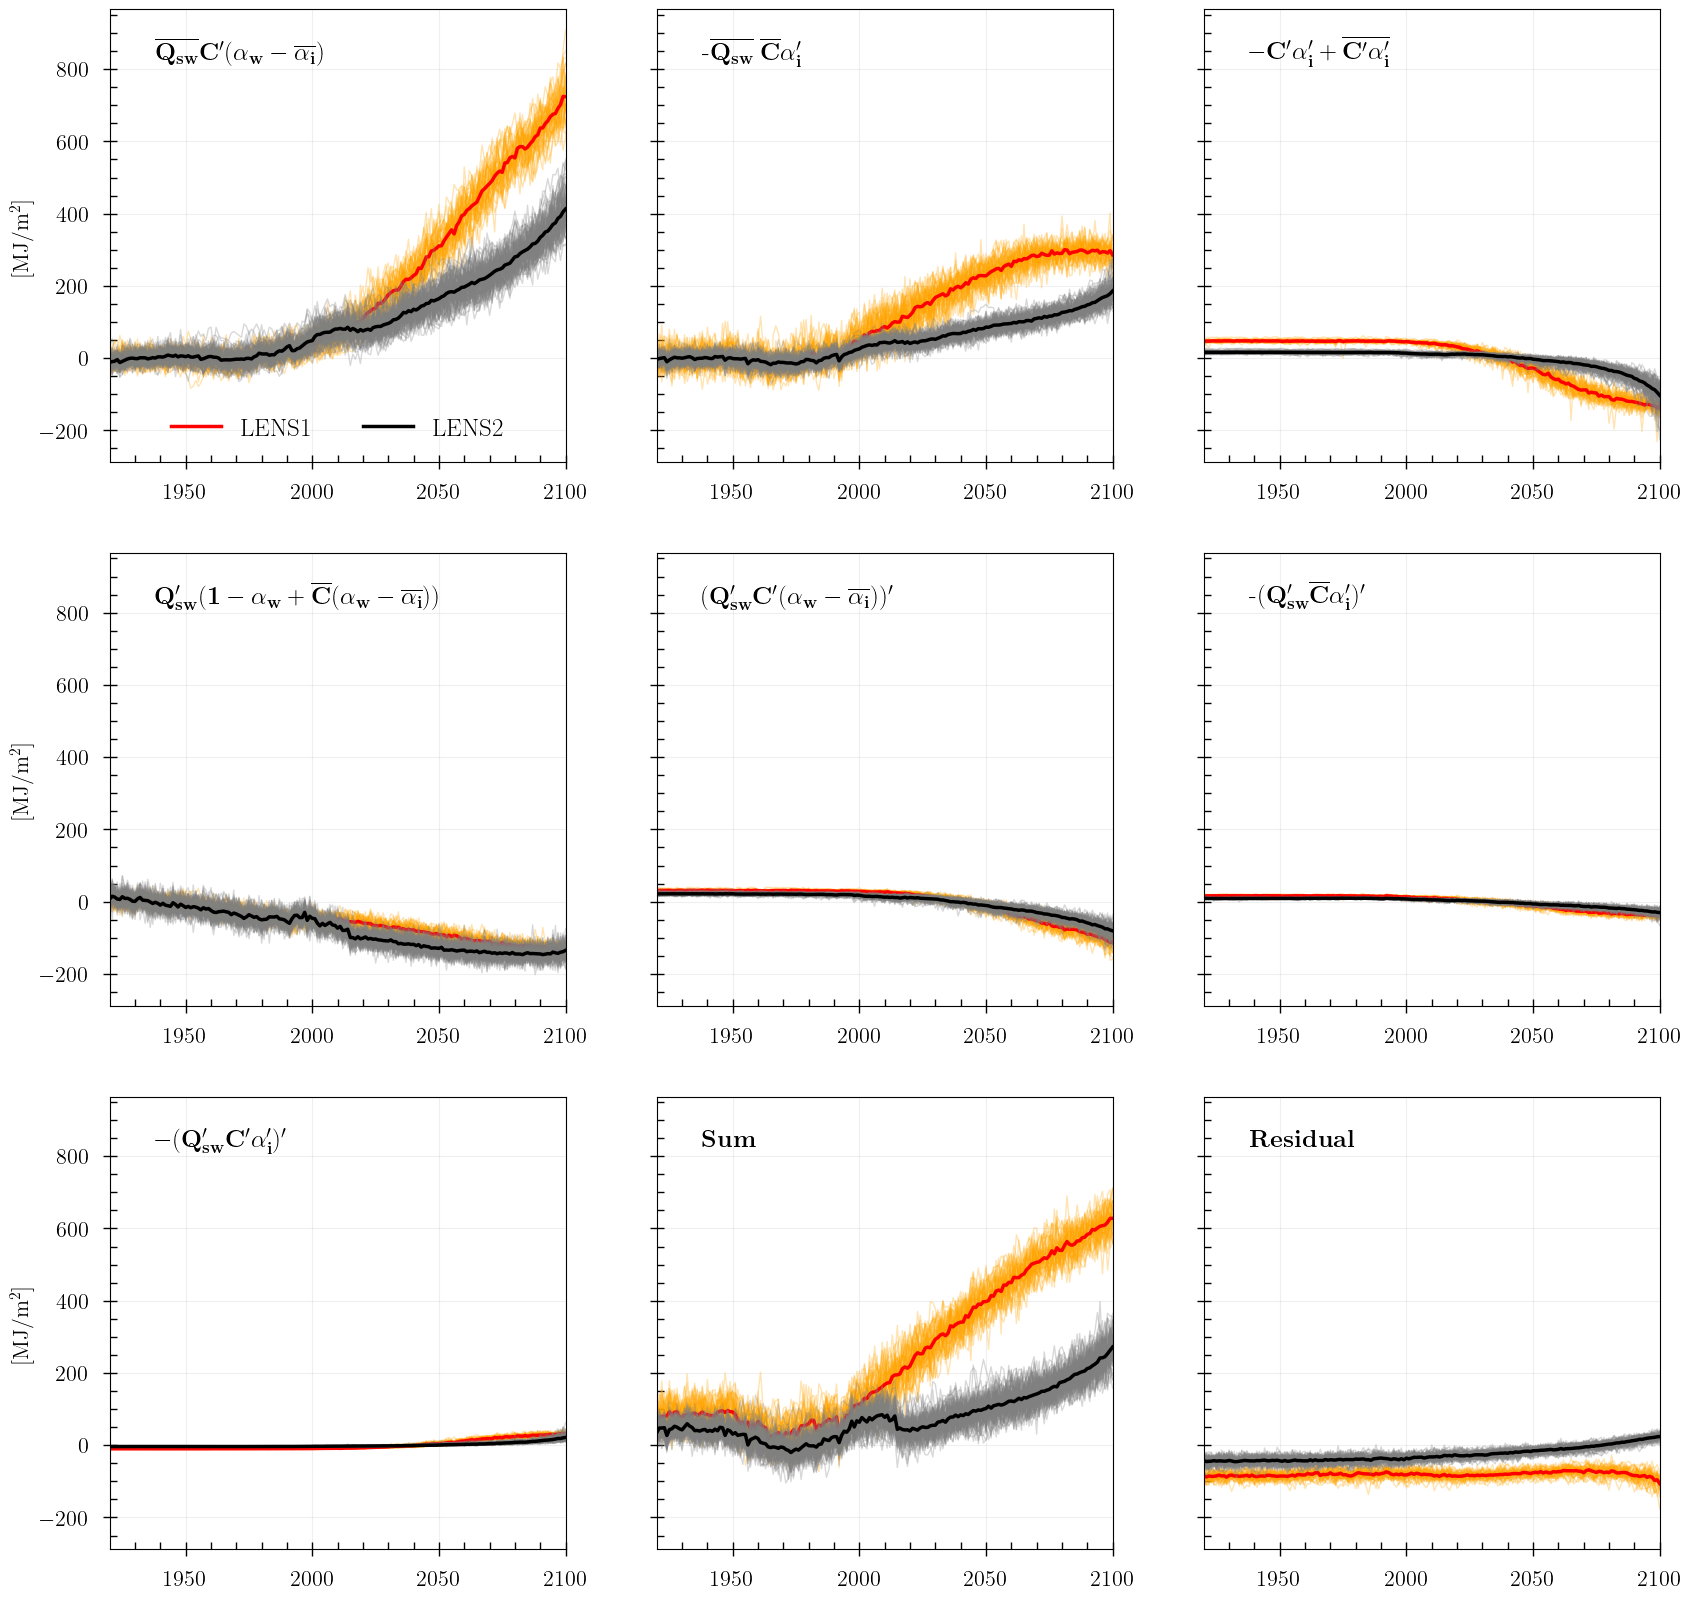

In [26]:
%%time

fig, ax = plt.subplots(ncols=3, nrows=3, sharey=True, figsize=(20, 20))
ax = ax.flatten()

ax_nums = np.linspace(0, 8, 9, dtype=int)



# ------------------------------------------------------
# Plotting loop
for i, variable in zip(ax_nums, ds_mjja_LENS1.data_vars):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS1.ensemble:
        ax[i].plot(ds_mjja_LENS1.year, 1e-6*ds_new_LENS1_accum[variable].sel(ensemble=ensemble),
                   color='orange', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS1_mean.year, 1e-6*ds_new_LENS1_accum[variable].mean('ensemble'),
               c='r', lw=2.5, label='LENS1')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS1.year.min().item(), ds_mjja_LENS1.year.max().item())
    
for i, variable in zip(ax_nums, ds_mjja_LENS2.data_vars):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS2.ensemble:
        ax[i].plot(ds_mjja_LENS2.year, 1e-6*ds_new_LENS2_accum[variable].sel(ensemble=ensemble),
                   color='gray', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS2_mean.year, 1e-6*ds_new_LENS2_accum[variable].mean('ensemble'),
               c='k', lw=2.5, label='LENS2')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS2.year.min().item(), ds_mjja_LENS2.year.max().item())




# ------------------------------------------------------
# Labels
ax[0].set_ylabel(r'[MJ/m$^2$]', fontsize=16)
ax[3].set_ylabel(r'[MJ/m$^2$]', fontsize=16)
ax[6].set_ylabel(r'[MJ/m$^2$]', fontsize=16)

# ax[0].set_xlim(2007,2011)
#ax[0].set_ylim(-1e10, 1e10)

# Math texts
ax[0].text(0.1, 0.89, r'$\mathbf{\overline{Q_{sw}}C^\prime (\alpha_w  - \overline{\alpha_{i}})}$', fontsize=18, transform=ax[0].transAxes)
ax[1].text(0.1, 0.89, r'-$\mathbf{\overline{Q_{sw}} \; \overline{C}\alpha_{i}^\prime}$', fontsize=18, transform=ax[1].transAxes)
ax[2].text(0.1, 0.89, r'$\mathbf{-C^\prime \alpha_{i}^\prime + \overline{C^\prime \alpha_i^\prime}}$', fontsize=18, transform=ax[2].transAxes)
ax[3].text(0.1, 0.89, r'$\mathbf{Q_{sw}^\prime (1- \alpha_w + \overline{C} (\alpha_w - \overline{\alpha_i}))}$', fontsize=18, transform=ax[3].transAxes)
ax[4].text(0.1, 0.89, r'$\mathbf{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}$', fontsize=18, transform=ax[4].transAxes)
ax[5].text(0.1, 0.89, r'-$\mathbf{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[5].transAxes)
ax[6].text(0.1, 0.89, r'$-\mathbf{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[6].transAxes)
ax[7].text(0.1, 0.89, r'\textbf{Sum}', fontsize=18, transform=ax[7].transAxes)
ax[8].text(0.1, 0.89, r'\textbf{Residual}', fontsize=18, transform=ax[8].transAxes)


ax[0].legend(loc='lower center', ncol=2, frameon=False, fontsize=18)

# plt.savefig('figs/solar_accumulation_allpanels.png', format='png', bbox_inches='tight', dpi=300)


In [27]:
(ds_new_LENS1_accum['I'].isel(year=93) - ds_new_LENS1_accum['I'].isel(year=93-10)).mean('ensemble')

(ds_new_LENS2_accum['I'].isel(year=93) - ds_new_LENS2_accum['I'].isel(year=93-10)).mean('ensemble')

<xarray.DataArray 'I' ()>
array(14603975.63069201)
Attributes:
    units:          1
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [28]:
(ds_new_LENS1_accum['sum'].isel(year=140) - ds_new_LENS1_accum['sum'].isel(year=93)).mean('ensemble')

<xarray.DataArray 'sum' ()>
array(2.60461523e+08)
Attributes:
    units:          %
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    comment:        none
    cell_methods:   time: mean
    time_rep:       averaged

In [29]:
(ds_new_LENS2_accum['sum'].isel(year=140) - ds_new_LENS2_accum['sum'].isel(year=93)).mean('ensemble')

<xarray.DataArray 'sum' ()>
array(51783700.54810825)
Attributes:
    units:          1
    long_name:      ice area  (aggregate)
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

### Plotting just the four panels

CPU times: user 344 ms, sys: 4.47 ms, total: 349 ms
Wall time: 442 ms


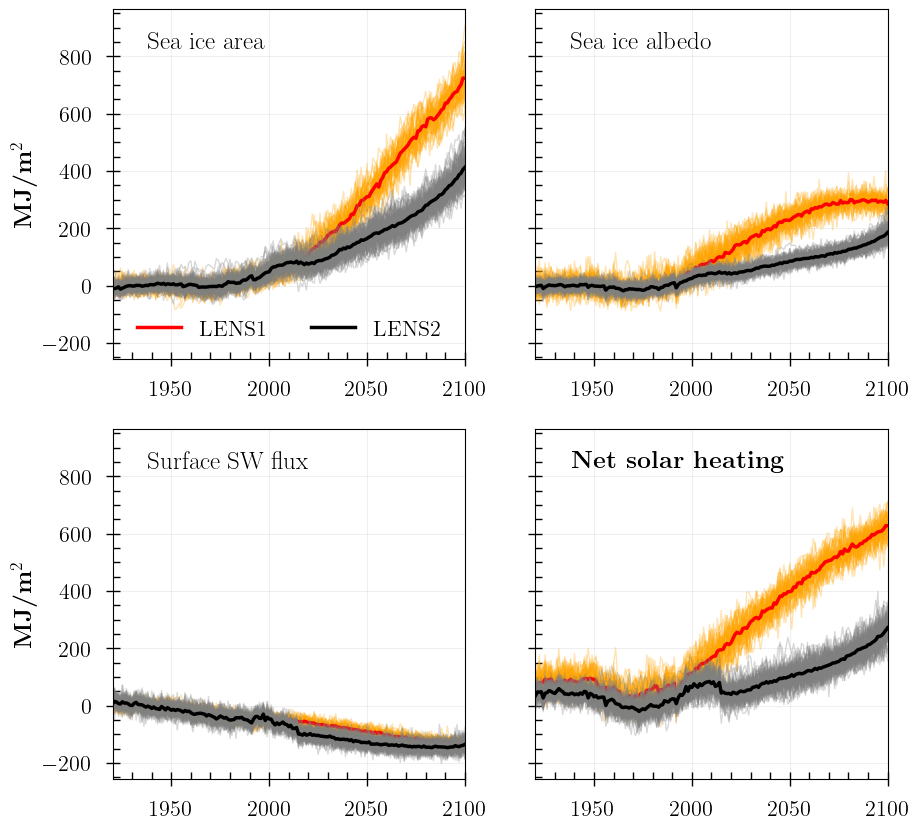

In [31]:
%%time

fig, ax = plt.subplots(ncols=2, nrows=2, sharey=True, figsize=(10,10))
ax = ax.flatten()

ax_nums = np.linspace(0, 3, 4, dtype=int)


variables_to_plot = ['I','II','IV','sum']

# ------------------------------------------------------
# Plotting loop
for i, variable in zip(ax_nums, variables_to_plot):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS1.ensemble:
        ax[i].plot(ds_mjja_LENS1.year, ds_new_LENS1_accum[variable].sel(ensemble=ensemble)/1e6,
                   color='orange', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS1_mean.year, ds_new_LENS1_accum[variable].mean('ensemble')/1e6,
               c='r', lw=2.5, label='LENS1')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS1.year.min().item(), ds_mjja_LENS1.year.max().item())
    
for i, variable in zip(ax_nums, variables_to_plot):
    # Plot each ensemble member (faint lines)
    for ensemble in ds_mjja_LENS2.ensemble:
        ax[i].plot(ds_mjja_LENS2.year, ds_new_LENS2_accum[variable].sel(ensemble=ensemble)/1e6,
                   color='gray', alpha=0.3, lw=1)

    # Plot ensemble mean (thicker black line)
    ax[i].plot(ds_mjja_LENS2_mean.year, ds_new_LENS2_accum[variable].mean('ensemble')/1e6,
               c='k', lw=2.5, label='LENS2')

    ax[i].tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    ax[i].yaxis.set_minor_locator(AutoMinorLocator())
    ax[i].tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax[i].grid(alpha=0.2)

    ax[i].set_xlim(ds_mjja_LENS2.year.min().item(), ds_mjja_LENS2.year.max().item())
    ax[i].set_xlim(1920, 2100)
    # ax[i].set_ylim(-2e4, 4.5e4)



# ------------------------------------------------------
# Labels

ax[0].set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)
ax[2].set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)

# ax[6].set_ylabel(r'[W/m$^2$]', fontsize=16)

# Math texts
ax[0].text(0.1, 0.89, r'Sea ice area', fontsize=18, transform=ax[0].transAxes)
ax[1].text(0.1, 0.89, r'Sea ice albedo', fontsize=18, transform=ax[1].transAxes)
# ax[2].text(0.1, 0.89, r'$\mathbf{-C^\prime \alpha_{i}^\prime + \overline{C^\prime \alpha_i^\prime}}$', fontsize=18, transform=ax[2].transAxes)
ax[2].text(0.1, 0.89, r'Surface SW flux ', fontsize=18, transform=ax[2].transAxes)
# ax[4].text(0.1, 0.89, r'$\mathbf{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}$', fontsize=18, transform=ax[4].transAxes)
# ax[5].text(0.1, 0.89, r'-$\mathbf{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[5].transAxes)
# ax[6].text(0.1, 0.89, r'$-\mathbf{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}$', fontsize=18, transform=ax[6].transAxes)
ax[3].text(0.1, 0.89, r'\textbf{Net solar heating}', fontsize=18, transform=ax[3].transAxes)
# ax[8].text(0.1, 0.89, r'\textbf{Residual}', fontsize=18, transform=ax[8].transAxes)


ax[0].legend(loc='lower center', ncol=2, frameon=False, fontsize=16)

# plt.savefig('../figs/solar_heating_accum_terms.png', format='png', bbox_inches='tight', dpi=300)


### Contributions to shortwave forcing at the surface

In [110]:
# %%time

# fig, ax = plt.subplots(ncols=2, nrows=2, sharey=True, figsize=(16, 8))
# ax = ax.flatten()

# # Setup
# months = [5, 6, 7, 8]
# colors = ['k', 'goldenrod', 'green']

# # Collect variables and optional labels (edit as needed)
# variables = [
#     ds_new_LENS2.IV, ds_q_prime_LENS2.q_prime_ice, ds_q_prime_LENS2.q_prime_ocn
# ]


# labels = [ r'$\mathbf{Q_{sw}^\prime (1- \alpha_w + \overline{C} (\alpha_w - \overline{\alpha_i}))}$',
#             'on ice',
#            'on open ocean'
# ]

# for num, month in zip(np.linspace(0,4,5, dtype=int), months):
#     # Loop through variables and plot ensemble members
#     for i, var in enumerate(variables):
#         var_month = var.isel(time=(var.groupby('time.month').groups)[month])
#         for ens in var_month.ensemble:
#             ax[num].plot(var_month.time, var_month.sel(ensemble=ens), color=colors[i], alpha=0.1)
    
#     # White outlines for mean lines
#     for i, var in enumerate(variables):
#         var_month = var.isel(time=(var.groupby('time.month').groups)[month])
#         ax[num].plot(var_month.time, var_month.mean(dim='ensemble'), color='white', lw=2.5)
    
#     # Mean lines with assigned colors
#     for i, var in enumerate(variables):
#         var_month = var.isel(time=(var.groupby('time.month').groups)[month])
#         ax[num].plot(var_month.time, var_month.mean(dim='ensemble'), color=colors[i], lw=2, label=labels[i])
    
#     # Formatting
#     ax[num].tick_params(which='both',
#                    labelcolor='k',
#                    labelsize=16,
#                    direction='inout',
#                    width=1,
#                    length=10,
#                    pad=10)
    
#     ax[num].xaxis.set_minor_locator(AutoMinorLocator())
#     ax[num].yaxis.set_minor_locator(AutoMinorLocator())
#     ax[num].tick_params(which='minor', direction='in', length=5, width=1, color='k')
#     ax[num].grid(alpha=0.2)
    
    
#     # Set x-limits for June (month = 6)
#     ax[num].set_xlim(
#         ds_new_LENS2.isel(time=(ds_new_LENS2.groupby('time.month').groups)[month]).time.sel(time='1850-01', method='nearest'),
#         ds_new_LENS2.isel(time=(ds_new_LENS2.groupby('time.month').groups)[month]).time.sel(time='2100-12', method='nearest')
#     )
    
# ax[0].set_ylabel(r' [W/m$^2$]', fontsize=16)
# ax[2].set_ylabel(r' [W/m$^2$]', fontsize=16)

# ax[0].legend(loc='upper center', ncol=3, frameon=False, fontsize=12)
# ax[0].set_title('May', fontsize=14)
# ax[1].set_title('June', fontsize=14)
# ax[2].set_title('July', fontsize=14)
# ax[3].set_title('Aug', fontsize=14)
# # Save if needed

# plt.tight_layout()
# # plt.savefig('figs/q_prime_decomp_lens1.png', format='png', bbox_inches='tight', dpi=300)


In [111]:
# %%time
# fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, sharey=True)
# axes = axes.flatten()

# # Months: May (5), June (6), July (7), Aug (8)
# months = [5, 6, 7, 8]
# colors = ['k', 'goldenrod', 'green']

# # -------------------- LENS2 --------------------
# variables_LENS2 = [
#     ds_new_LENS2.IV,
#     ds_q_prime_LENS2.q_prime_ice,
#     ds_q_prime_LENS2.q_prime_ocn
# ]

# labels = [
#     r'$\mathbf{Q_{sw}^\prime (1- \alpha_w + \overline{C} (\alpha_w - \overline{\alpha_i}))}$',
#     'on ice',
#     'on open ocean'
# ]

# for i, var in enumerate(variables_LENS2):
#     var_mjja = var.sel(time=var['time.month'].isin(months)).groupby('time.year').mean('time')
#     years = var_mjja.year.values

#     # Plot ensemble members
#     for ens in var_mjja.ensemble:
#         axes[0].plot(years, var_mjja.sel(ensemble=ens), color=colors[i], alpha=0.1)

#     # White outline for mean
#     axes[0].plot(years, var_mjja.mean(dim='ensemble'), color='white', lw=2.5)
#     # Ensemble mean
#     axes[0].plot(years, var_mjja.mean(dim='ensemble'), color=colors[i], lw=2, label=labels[i])

# axes[0].set_title("LENS2", fontsize=18)
# axes[0].legend(loc='upper center', ncol=3, frameon=False, fontsize=14)

# # -------------------- LENS1 --------------------
# variables_LENS1 = [
#     ds_new_LENS1.IV,
#     ds_q_prime_LENS1.q_prime_ice,
#     ds_q_prime_LENS1.q_prime_ocn
# ]

# for i, var in enumerate(variables_LENS1):
#     var_mjja = var.sel(time=var['time.month'].isin(months)).groupby('time.year').mean('time')
#     years = var_mjja.year.values

#     # Plot ensemble members
#     for ens in var_mjja.ensemble:
#         axes[1].plot(years, var_mjja.sel(ensemble=ens), color=colors[i], alpha=0.1)

#     # White outline for mean
#     axes[1].plot(years, var_mjja.mean(dim='ensemble'), color='white', lw=2.5)
#     # Ensemble mean
#     axes[1].plot(years, var_mjja.mean(dim='ensemble'), color=colors[i], lw=2, label=labels[i])

# axes[1].set_title("LENS1", fontsize=18)
# axes[1].legend(loc='upper center', ncol=3, frameon=False, fontsize=14)

# # -------------------- Shared Formatting --------------------
# for ax in axes:
#     ax.set_ylabel(r'[W/m$^2$]', fontsize=16)
#     ax.tick_params(which='both',
#                    labelcolor='k',
#                    labelsize=14,
#                    direction='inout',
#                    width=1,
#                    length=10,
#                    pad=10)
#     ax.xaxis.set_minor_locator(AutoMinorLocator())
#     ax.yaxis.set_minor_locator(AutoMinorLocator())
#     ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
#     ax.grid(alpha=0.2)
#     ax.set_xlim(years.min(), years.max())

# axes[1].set_xlabel("Year", fontsize=16)

# plt.tight_layout()
# plt.savefig("figs/q_prime_decomp_MJJA_LENS1vs2.png", dpi=300, bbox_inches="tight")


### terms 1 and 2

CPU times: user 226 ms, sys: 870 µs, total: 227 ms
Wall time: 301 ms


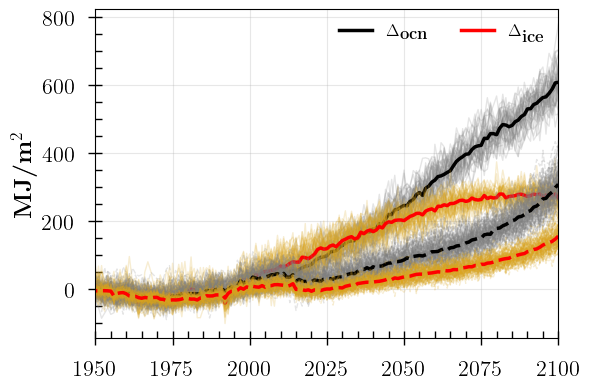

In [33]:
%%time
fig, ax = plt.subplots(figsize=(6, 4))

# --- Pick the first 2 terms explicitly ---
variables = [list(ds_mjja_LENS1.data_vars)[0],
             list(ds_mjja_LENS1.data_vars)[1]]

labels = [r"$\Delta_{\textbf{ocn}}$", r"$\Delta_{\textbf{ice}}$"]

# Colors for thick ensemble-mean lines
mean_colors = ["k", "red"]  
# Colors for faint ensemble members
faint_colors = ["grey", "goldenrod"]


# --- Plot LENS1 ---
for idx, (var, lab, mean_col, faint_col) in enumerate(zip(variables, labels, mean_colors, faint_colors)):

    if idx == 0:  # sea ice → add q_prime_ocn
        data_LENS1 = ds_new_LENS1_accum[var] + ds_q_prime_LENS1_accum['q_prime_ocn']
    elif idx == 1:  # albedo → add q_prime_ice
        data_LENS1 = ds_new_LENS1_accum[var] + ds_q_prime_LENS1_accum['q_prime_ice']
    else:
        data_LENS1 = ds_new_LENS1_accum[var]

    # faint ensemble members (LENS1)
    for ens in ds_mjja_LENS1.ensemble:
        ax.plot(ds_mjja_LENS1.year,
                data_LENS1.sel(ensemble=ens) / 1e6,
                color=faint_col, alpha=0.2, lw=1)

    # thick ensemble mean (LENS1 solid)
    ax.plot(ds_mjja_LENS1_mean.year,
            data_LENS1.mean('ensemble') / 1e6,
            color=mean_col, lw=2.5, label=f"{lab}")

# --- Plot LENS2 ---
for idx, (var, lab, mean_col, faint_col) in enumerate(zip(variables, labels, mean_colors, faint_colors)):

    if idx == 0:  # sea ice → add q_prime_ocn
        data_LENS2 = ds_new_LENS2_accum[var] + ds_q_prime_LENS2_accum['q_prime_ocn']
    elif idx == 1:  # albedo → add q_prime_ice
        data_LENS2 = ds_new_LENS2_accum[var] + ds_q_prime_LENS2_accum['q_prime_ice']
    else:
        data_LENS2 = ds_new_LENS2_accum[var]

    # faint ensemble members (LENS2)
    for ens in ds_mjja_LENS2.ensemble:
        ax.plot(ds_mjja_LENS2.year,
                data_LENS2.sel(ensemble=ens) / 1e6,
                color=faint_col, alpha=0.2, lw=1, ls="--")

    # thick ensemble mean (LENS2 dashed)
    ax.plot(ds_mjja_LENS2_mean.year,
            data_LENS2.mean('ensemble') / 1e6,
            color=mean_col, lw=2.5, ls="--")#, label=f"{lab} (LENS2)")
    ax.tick_params(which='both',
               labelcolor='k', 
               labelsize=16, 
               direction='inout',
               width=1,
               length=10,
               pad=10)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax.grid(alpha=0.2)

# --- Axis formatting ---
ax.set_xlim(1950, 2100)
# ax.set_ylim(-4e3, 3e4)
ax.set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)
# ax.set_title("LENS1 vs LENS2 (Sea ice & Albedo)", fontsize=14)
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=12, ncol=2)

plt.tight_layout()
# plt.savefig("../figs/cum_solar_heating_curves.png", dpi=300, bbox_inches="tight")
# plt.show()


### final figure

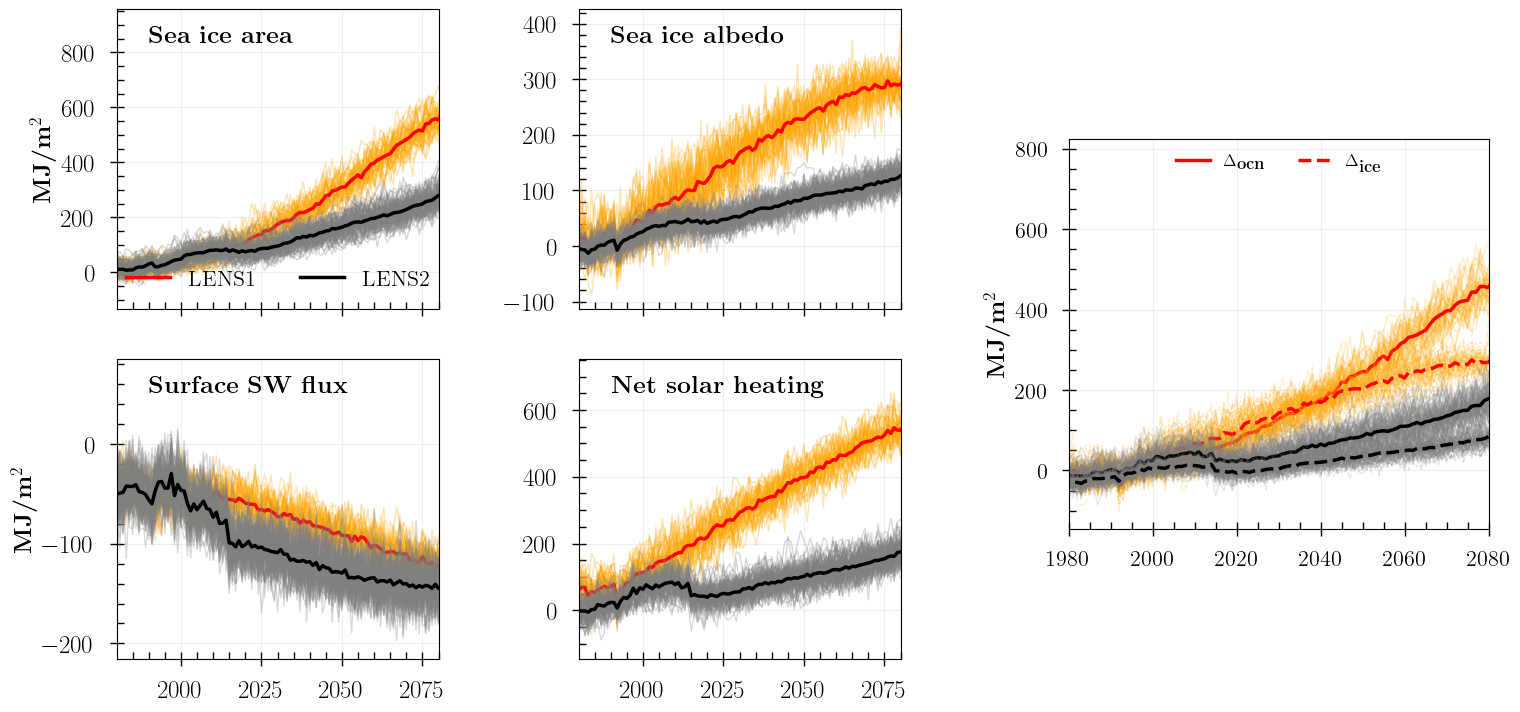

In [36]:
# --- Figure setup ---
fig = plt.figure(figsize=(14, 10))

# --- Adjust widths: leave room for third plot on the right ---
# left, bottom, width, height (fractions of figure)
ax_width = 0.23  # slightly narrower to leave space
ax_height = 0.3

# Row 1
ax1 = fig.add_axes([0.05, 0.45, ax_width, ax_height])  # col 1
ax2 = fig.add_axes([0.38, 0.45, ax_width, ax_height])  # col 2

# Row 2
ax3 = fig.add_axes([0.05, 0.1, ax_width, ax_height])   # col 1
ax4 = fig.add_axes([0.38, 0.1, ax_width, ax_height])   # col 2

axes_2x2 = [ax1, ax2, ax3, ax4]
ax_nums = np.arange(4)
variables_to_plot = ['I','II','IV','sum']

# --- Plot 2x2 panels ---
for i, variable in zip(ax_nums, variables_to_plot):
    ax = axes_2x2[i]
    
    # LENS1
    for ensemble in ds_mjja_LENS1.ensemble:
        ax.plot(ds_mjja_LENS1.year, ds_new_LENS1_accum[variable].sel(ensemble=ensemble)/1e6,
                color='orange', alpha=0.3, lw=1)
    ax.plot(ds_mjja_LENS1_mean.year, ds_new_LENS1_accum[variable].mean('ensemble')/1e6,
            c='r', lw=2.5, label='LENS1')
    
    # LENS2
    for ensemble in ds_mjja_LENS2.ensemble:
        ax.plot(ds_mjja_LENS2.year, ds_new_LENS2_accum[variable].sel(ensemble=ensemble)/1e6,
                color='gray', alpha=0.3, lw=1)
    ax.plot(ds_mjja_LENS2_mean.year, ds_new_LENS2_accum[variable].mean('ensemble')/1e6,
            c='k', lw=2.5, label='LENS2')
    
    # Formatting
    ax.set_xlim(1980, 2080)
    # ax.set_ylim(-1.5e4, 2.5e4)
    ax.tick_params(which='both', labelsize=18, direction='inout', width=1, length=10, pad=10)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
    ax.grid(alpha=0.2)

# --- Remove x ticks from top row ---
for ax in [ax1, ax2]:
    ax.set_xticklabels([])
    ax.tick_params(labelbottom=False)  # hides labels but keeps minor/major ticks visible


# Labels
ax1.set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)
ax3.set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)
ax1.legend(loc='lower center', ncol=2, frameon=False, fontsize=16)

ax1.text(0.1, 0.89, r'\textbf{Sea ice area}', fontsize=18, transform=ax1.transAxes)
ax2.text(0.1, 0.89, r'\textbf{Sea ice albedo}', fontsize=18, transform=ax2.transAxes)
ax3.text(0.1, 0.89, r'\textbf{Surface SW flux}', fontsize=18, transform=ax3.transAxes)
ax4.text(0.1, 0.89, r'\textbf{Net solar heating}', fontsize=18, transform=ax4.transAxes)

# --- Third plot (centered vertically, now with space horizontally) ---
# Compute center of 2x2 vertically
top_2x2 = ax1.get_position().y1
bottom_2x2 = ax3.get_position().y0
center_y = bottom_2x2 + (top_2x2 - bottom_2x2)/2

height_third = 0.6 * (top_2x2 - bottom_2x2)  # half height of 2x2 grid
bottom_third = center_y - height_third/2

left_third = 0.73
width_third = 0.3

ax5 = fig.add_axes([left_third, bottom_third, width_third, height_third])

# --- Plot cumulative LENS1/LENS2 data in ax5 ---

variables = [list(ds_mjja_LENS1.data_vars)[0],
             list(ds_mjja_LENS1.data_vars)[1]]
labels = [r"$\Delta_{\textbf{ocn}}$", r"$\Delta_{\textbf{ice}}$"]

# Line styles: solid for ocn, dashed for ice
line_styles = ["-", "--"]

# Color definitions
ensemble_colors = {
    "LENS1": "orange",
    "LENS2": "grey"
}
mean_colors = {
    "LENS1": "red",
    "LENS2": "black"
}

# --- LENS1 ---
for idx, (var, lab, ls) in enumerate(zip(variables, labels, line_styles)):
    data_LENS1 = ds_new_LENS1_accum[var].copy()
    if idx == 0:
        data_LENS1 += ds_q_prime_LENS1_accum['q_prime_ocn']
    else:
        data_LENS1 += ds_q_prime_LENS1_accum['q_prime_ice']
    
    # Individual ensemble members (faint)
    for ens in ds_mjja_LENS1.ensemble:
        ax5.plot(ds_mjja_LENS1.year, data_LENS1.sel(ensemble=ens)/1e6,
                 color=ensemble_colors["LENS1"], alpha=0.2, lw=1, ls=ls)
    # Ensemble mean (bold)
    ax5.plot(ds_mjja_LENS1_mean.year, data_LENS1.mean('ensemble')/1e6,
             color=mean_colors["LENS1"], lw=2.5, ls=ls, label=f"{lab}")

# --- LENS2 ---
for idx, (var, lab, ls) in enumerate(zip(variables, labels, line_styles)):
    data_LENS2 = ds_new_LENS2_accum[var].copy()
    if idx == 0:
        data_LENS2 += ds_q_prime_LENS2_accum['q_prime_ocn']
    else:
        data_LENS2 += ds_q_prime_LENS2_accum['q_prime_ice']
    
    # Individual ensemble members (faint)
    for ens in ds_mjja_LENS2.ensemble:
        ax5.plot(ds_mjja_LENS2.year, data_LENS2.sel(ensemble=ens)/1e6,
                 color=ensemble_colors["LENS2"], alpha=0.2, lw=1, ls=ls)
    # Ensemble mean (bold)
    ax5.plot(ds_mjja_LENS2_mean.year, data_LENS2.mean('ensemble')/1e6,
             color=mean_colors["LENS2"], lw=2.5, ls=ls)

# --- Formatting ---
ax5.set_xlim(1980, 2080)
# ax5.set_ylim(-5e3, 2e4)
ax5.set_ylabel(r"\textbf{MJ/m$^2$}", fontsize=18)
ax5.tick_params(which='both', labelsize=16, direction='inout', width=1, length=10, pad=10)
ax5.xaxis.set_minor_locator(AutoMinorLocator())
ax5.yaxis.set_minor_locator(AutoMinorLocator())
ax5.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax5.grid(alpha=0.2)
ax5.legend(frameon=False, loc='upper center', fontsize=12, ncol=2)

# plt.savefig("../figs/cumulative_heating.pdf", dpi=300, bbox_inches="tight")
plt.show()

